In [8]:
# Celda 1 — carga de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.append('.')
from conexion_datos import cargar_margen_por_venta

sns.set_style("whitegrid")

df = cargar_margen_por_venta()
df.head()

,id_venta,fecha_venta,nombre_sucursal,ciudad,region,nombre_producto,categoria,cantidad_vendida,precio_venta,costo_unitario,total_venta,margen_total,margen_pct
0,1,2024-09-25,Sucursal Este,Viña del Mar,Valparaíso,Laptop,Electrónica,2,1200.0,800.0,2400.0,800.0,33.3
1,2,2024-07-12,Sucursal Sur,Concepción,Sur,Auriculares,Accesorios,7,70.0,40.0,490.0,210.0,42.9
2,3,2024-12-02,Sucursal Norte,Santiago,Centro,Laptop,Electrónica,6,1200.0,800.0,7200.0,2400.0,33.3
3,4,2024-05-04,Sucursal Sur,Concepción,Sur,Auriculares,Accesorios,7,70.0,40.0,490.0,210.0,42.9
4,5,2024-08-30,Sucursal Sur,Concepción,Sur,Tablet,Electrónica,2,500.0,300.0,1000.0,400.0,40.0


In [14]:
print("Filas cargadas:", df.shape[0])
print(df.groupby('nombre_producto')['margen_total'].sum().sort_values(ascending=False))

Filas cargadas: 1105
nombre_producto
Laptop         382800.0
Smartphone     220200.0
Tablet         156600.0
Monitor         86400.0
Impresora       49200.0
Auriculares     25200.0
Teclado         25050.0
Mouse           11445.0
Name: margen_total, dtype: float64


nombre_producto
Laptop         382800.0
Smartphone     220200.0
Tablet         156600.0
Monitor         86400.0
Impresora       49200.0
Auriculares     25200.0
Teclado         25050.0
Mouse           11445.0
Name: margen_total, dtype: float64


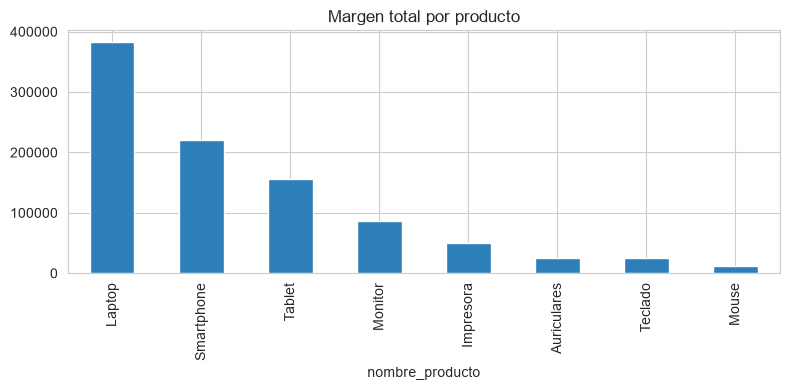

Guardado en: C:\Users\yenni\Desktop\i_tem\proyecto_item_optimizacion_margen\06_Reportes\img\margen_por_producto.png
Existe el archivo: True
Tamaño en bytes: 35547


In [15]:
# Celda 2 — crear la carpeta de salida si no existe (evita error en savefig)
import os
os.makedirs('../06_Reportes/img', exist_ok=True)
print("Directorio actual:", os.getcwd())

Directorio actual: C:\Users\yenni\Desktop\i_tem\proyecto_item_optimizacion_margen\04_Python


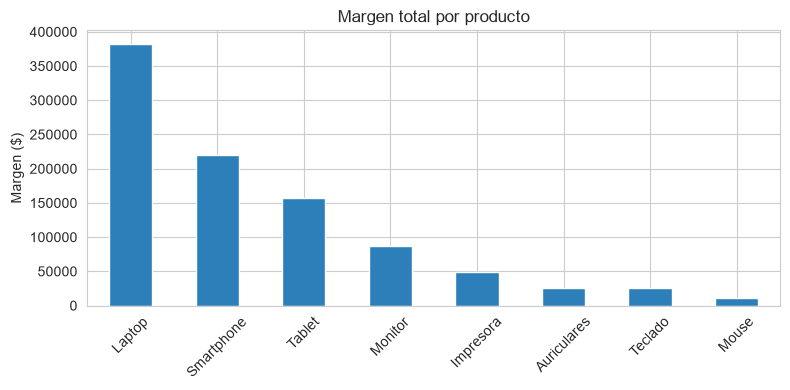

In [16]:
# Celda 3 — margen total por producto (barras)
plt.figure(figsize=(8,4))
df.groupby('nombre_producto')['margen_total'].sum().sort_values(ascending=False).plot(
    kind='bar', color='#2c7fb8'
)
plt.title('Margen total por producto')
plt.ylabel('Margen ($)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../06_Reportes/img/margen_por_producto.png', dpi=150)
plt.show()

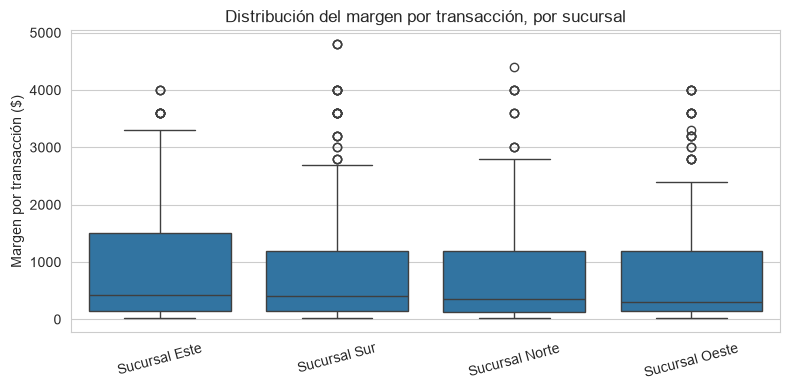

In [17]:
# Celda 4 — distribución del margen por transacción, por sucursal (boxplot)
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='nombre_sucursal', y='margen_total')
plt.title('Distribución del margen por transacción, por sucursal')
plt.ylabel('Margen por transacción ($)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../06_Reportes/img/margen_boxplot_sucursal.png', dpi=150)
plt.show()

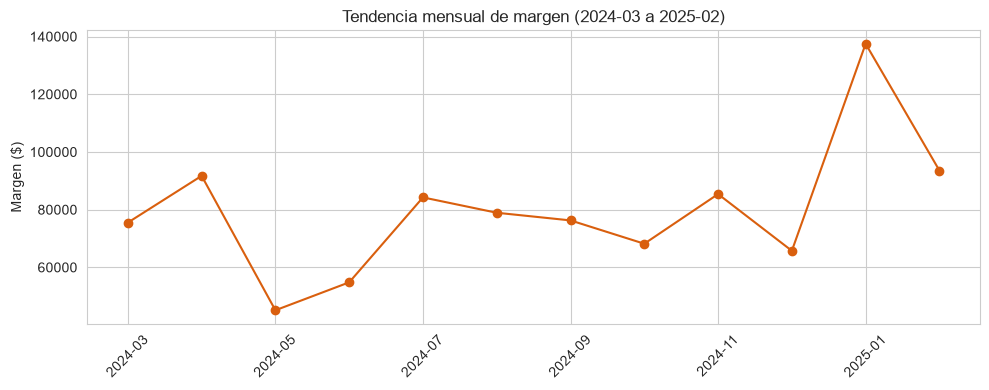

In [18]:
# Celda 5 — tendencia mensual de margen (línea)
df['mes'] = pd.to_datetime(df['fecha_venta']).dt.to_period('M').astype(str)
tendencia = df.groupby('mes')['margen_total'].sum()

plt.figure(figsize=(10,4))
tendencia.plot(marker='o', color='#d95f0e')
plt.title('Tendencia mensual de margen (2024-03 a 2025-02)')
plt.ylabel('Margen ($)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../06_Reportes/img/tendencia_margen_mensual.png', dpi=150)
plt.show()

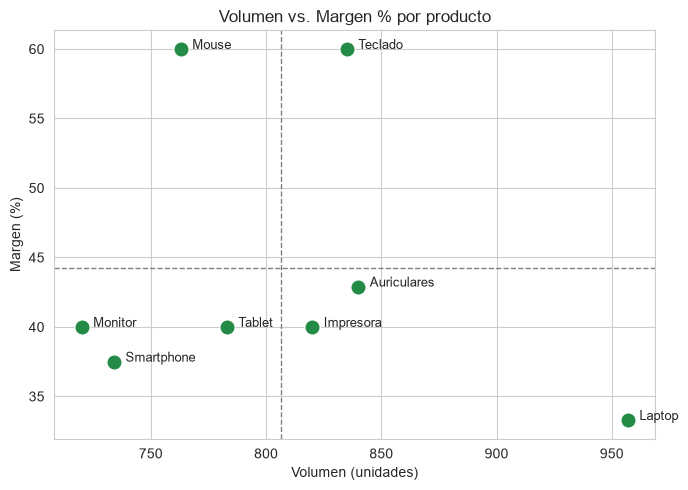

In [19]:
# Celda 6 — margen % por producto (catálogo) vs volumen, para visualizar el hallazgo de Laptop
resumen = df.groupby('nombre_producto').agg(
    volumen=('cantidad_vendida', 'sum'),
    margen_pct=('margen_pct', 'first')
).reset_index()

plt.figure(figsize=(7,5))
sns.scatterplot(data=resumen, x='volumen', y='margen_pct', s=120, color='#238b45')
for _, fila in resumen.iterrows():
    plt.text(fila['volumen']+5, fila['margen_pct'], fila['nombre_producto'], fontsize=9)
plt.axvline(resumen['volumen'].mean(), color='gray', linestyle='--', linewidth=1)
plt.axhline(resumen['margen_pct'].mean(), color='gray', linestyle='--', linewidth=1)
plt.title('Volumen vs. Margen % por producto')
plt.xlabel('Volumen (unidades)')
plt.ylabel('Margen (%)')
plt.tight_layout()
plt.savefig('../06_Reportes/img/cuadrante_volumen_margen.png', dpi=150)
plt.show()